# Train ResNeXt50 on OCTMNIST

In [1]:

from pathlib import Path
import os
import shutil
import sys

ROOT = Path.cwd().parents[1].resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault(
    "PYTHON_JULIAPKG_PROJECT",
    str(Path.home() / "Documents" / "dev" / "MAGENetRunner" / "python_utils"),
)
os.environ.setdefault("PYTHON_JULIAPKG_OFFLINE", "yes")
julia_exe = shutil.which("julia")
if julia_exe is not None:
    os.environ.setdefault("PYTHON_JULIAPKG_EXE", julia_exe)


In [2]:

import torch

from python_utils.medmnist_resnet_baseline import (
    DatasetConfig,
    build_model,
    clean_checkpoints,
    evaluate_loader,
    load_checkpoint,
    plot_training_curves,
    prepare_experiment,
    print_metrics,
    select_best_checkpoint,
    train_model,
)


/home/camilo/Documents/dev/MAGENetRunner/.CondaPkg/env/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:

SEED = 123
TRAIN_BATCH_SIZE = 128
EVAL_BATCH_SIZE = 512
EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 1e-4
USE_CLASS_WEIGHTS = True
RESIZE_TO = 224

CONFIG = DatasetConfig(
    dataset_name="OCTMNIST",
    train_file=str(ROOT / "datasets_pickle" / "OCTMNIST_64_train.jld2"),
    val_file=str(ROOT / "datasets_pickle" / "OCTMNIST_64_val.jld2"),
    test_file=str(ROOT / "datasets_pickle" / "OCTMNIST_64_test.jld2"),
    num_classes=4,
    batch_size=TRAIN_BATCH_SIZE,
    val_batch_size=EVAL_BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    use_class_weights=USE_CLASS_WEIGHTS,
    seed=SEED,
    resize_to=RESIZE_TO,
    output_dir="OCTMNIST/NN_baselines",
    experiment_name="resnext50_OCTMNIST",
    backbone_name="resnext50",
    nd=1,
    pretrained_weights="default",
)

CONFIG


DatasetConfig(dataset_name='OCTMNIST', train_file='/home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OCTMNIST_64_train.jld2', val_file='/home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OCTMNIST_64_val.jld2', test_file='/home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OCTMNIST_64_test.jld2', num_classes=4, batch_size=128, val_batch_size=512, epochs=30, lr=0.0001, weight_decay=0.0001, use_class_weights=True, seed=123, resize_to=224, output_dir='OCTMNIST/NN_baselines', experiment_name='resnext50_OCTMNIST', backbone_name='resnext50', nd=1, pretrained_weights='default')

In [4]:

CONTEXT = prepare_experiment(CONFIG)
MODEL = build_model(
    CONFIG.backbone_name,
    CONFIG.num_classes,
    pretrained_weights=CONFIG.pretrained_weights,
).to(CONTEXT.device)
OPTIMIZER = torch.optim.AdamW(
    MODEL.parameters(),
    lr=CONFIG.lr,
    weight_decay=CONFIG.weight_decay,
)


Reading /home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OCTMNIST_64_train.jld2
Reading /home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OCTMNIST_64_val.jld2
Reading /home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OCTMNIST_64_test.jld2
TORCH DEVICE cuda
N CPUS 16
CWD : /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines
Metrics file: /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/cnn_metrics_resnet.csv
TRAIN DATASET SIZE : 97477
VAL DATASET SIZE : 10832
TEST DATASET SIZE : 1000
normalization mean: [0.1894276887178421, 0.1894276887178421, 0.1894276887178421] | std: [0.20684342086315155, 0.20684342086315155, 0.20684342086315155]
class weights: [0.7277879118919373, 2.386101007461548, 3.1427972316741943, 0.5294670462608337]


In [5]:

METRICS_DF = train_model(CONTEXT, MODEL, OPTIMIZER)
METRICS_DF.tail()


Epoch [0/30], Train Loss: 1.3924, Train ACC: 0.4321, Train BACC: 0.2825
Epoch [0/30], Val Loss: 1.3921, Val ACC: 0.4369, Val BACC: 0.2901
Checkpoint saved at epoch 1 to /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoints/1.pth
Epoch [1/30], Train Loss: 0.2512, Train ACC: 0.9234, Train BACC: 0.9101
Epoch [1/30], Val Loss: 0.1547, Val ACC: 0.9499, Val BACC: 0.9494
Checkpoint saved at epoch 2 to /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoints/2.pth
Epoch [2/30], Train Loss: 0.1401, Train ACC: 0.9570, Train BACC: 0.9527
Epoch [2/30], Val Loss: 0.1363, Val ACC: 0.9634, Val BACC: 0.9579
Checkpoint saved at epoch 3 to /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoints/3.pth
Epoch [3/30], Train Loss: 0.1089, Train ACC: 0.9656, Train BACC: 0.9629
Epoch [3/30], Val Loss: 0.1177, Val ACC: 0.9713, Val BACC: 0.9635
Checkpo

,epoch,loss,val_loss,accuracy,val_accuracy,balanced_accuracy,val_balanced_accuracy
26,26,0.019703,0.201063,0.992552,0.979413,0.993246,0.967114
27,27,0.017056,0.220813,0.993711,0.977751,0.994303,0.964015
28,28,0.015571,0.230101,0.994132,0.977659,0.995006,0.963521
29,29,0.015974,0.219917,0.993752,0.974520,0.994668,0.963965
30,30,0.015921,0.213374,0.993814,0.976459,0.994753,0.963713


In [6]:

BEST_VAL_ACC_CKPT, METRICS_DF = select_best_checkpoint(CONTEXT, "val_accuracy")
BEST_VAL_ACC_MODEL = build_model(
    CONFIG.backbone_name,
    CONFIG.num_classes,
    pretrained_weights=CONFIG.pretrained_weights,
).to(CONTEXT.device)
load_checkpoint(BEST_VAL_ACC_MODEL, BEST_VAL_ACC_CKPT, CONTEXT.device)
VAL_ACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_ACC_MODEL,
    CONTEXT.val_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
TEST_ACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_ACC_MODEL,
    CONTEXT.test_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
print_metrics("Best Val-ACC checkpoint | Validation", VAL_ACC_METRICS)
print_metrics("Best Val-ACC checkpoint | Test", TEST_ACC_METRICS)


Best val_accuracy: epoch 26
Checkpoint to read: /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoints/26.pth
Loaded checkpoint /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoints/26.pth
Best Val-ACC checkpoint | Validation Accuracy: 0.979
Best Val-ACC checkpoint | Validation Balanced Accuracy: 0.967
Best Val-ACC checkpoint | Validation AUC: 0.996
Best Val-ACC checkpoint | Test Accuracy: 0.914
Best Val-ACC checkpoint | Test Balanced Accuracy: 0.914
Best Val-ACC checkpoint | Test AUC: 0.992


In [7]:

BEST_VAL_BACC_CKPT, METRICS_DF = select_best_checkpoint(CONTEXT, "val_balanced_accuracy")
BEST_VAL_BACC_MODEL = build_model(
    CONFIG.backbone_name,
    CONFIG.num_classes,
    pretrained_weights=CONFIG.pretrained_weights,
).to(CONTEXT.device)
load_checkpoint(BEST_VAL_BACC_MODEL, BEST_VAL_BACC_CKPT, CONTEXT.device)
VAL_BACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_BACC_MODEL,
    CONTEXT.val_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
TEST_BACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_BACC_MODEL,
    CONTEXT.test_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
print_metrics("Best Val-BACC checkpoint | Validation", VAL_BACC_METRICS)
print_metrics("Best Val-BACC checkpoint | Test", TEST_BACC_METRICS)


Best val_balanced_accuracy: epoch 12
Checkpoint to read: /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoints/12.pth
Loaded checkpoint /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoints/12.pth
Best Val-BACC checkpoint | Validation Accuracy: 0.976
Best Val-BACC checkpoint | Validation Balanced Accuracy: 0.969
Best Val-BACC checkpoint | Validation AUC: 0.996
Best Val-BACC checkpoint | Test Accuracy: 0.913
Best Val-BACC checkpoint | Test Balanced Accuracy: 0.913
Best Val-BACC checkpoint | Test AUC: 0.995


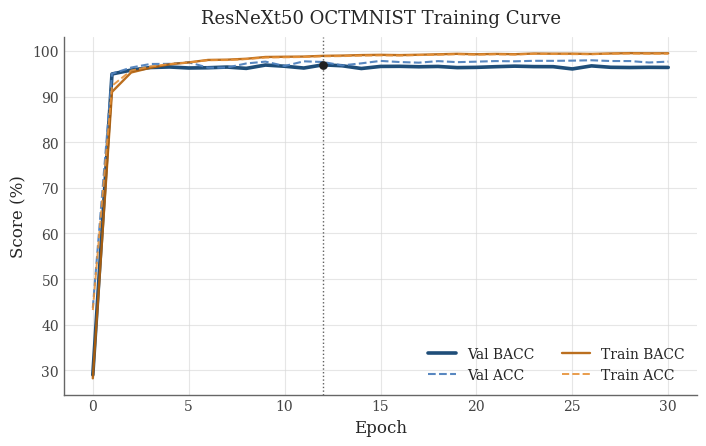

Saved plot to /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/training_curve_resnext50.png
Deleting: /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoints/11.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoints/5.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoints/17.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoints/19.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoints/3.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoints/6.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/OCTMNIST/NN_baselines/resnext50_OCTMNIST/DLmodels_resnet/checkpoi

In [8]:

PLOT_PATH = CONTEXT.folder / "training_curve_resnext50.png"
plot_training_curves(
    METRICS_DF,
    title="ResNeXt50 OCTMNIST Training Curve",
    output_path=PLOT_PATH,
)
clean_checkpoints(CONTEXT.checkpoint_dir, {BEST_VAL_ACC_CKPT, BEST_VAL_BACC_CKPT})
